In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from pynwb import TimeSeries
from pynwb import NWBHDF5IO
import pandas as pd
import numpy as np
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
import jax
os.chdir("..")

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(


In [96]:
nwbfile

Data type,object
Shape,"(4,)"
Array size,32.00 bytes
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),32
Compressed size (bytes),64
Compression ratio,0.5
Data type,float64
Shape,"(2223449, 6)"


In [2]:
path = "/stelmo/sam/c3po_datasets/sub-Han_desc-train_behavior+ecephys.nwb"

# nwb file
os.path.exists(path)
io = NWBHDF5IO(path, "r")
nwbfile = io.read()

# behavior data
data = []
joint_data = []
muscle_data = []
for object in nwbfile.objects.values():
    if isinstance(object, TimeSeries):
        for id_ in ["hand"]:
            if id_ in object.name.lower() or id_ in object.description.lower():
                data.append(object)
        id_ = "joint"
        if id_ in object.name.lower() or id_ in object.description.lower():
            joint_data.append(object)
        id_ = "muscle"
        if id_ in object.name.lower() or id_ in object.description.lower():
            muscle_data.append(object)

behavior_df = {}
for d in data:
    if d.name == "force":
        for i, dim in enumerate(
            ["force_x", "force_y", "force_z", "mom_x", "mom_y", "mom_z"]
        ):
            behavior_df[dim] = d.data[:, i]
        continue

    for i, dim in enumerate(["x", "y"]):
        behavior_df[f"{d.name}_{dim}"] = d.data[:, i]


behavior_df = pd.DataFrame(behavior_df, index=d.get_timestamps())
trials_df = nwbfile.trials.to_dataframe()

# spikes
units_df = nwbfile.units.to_dataframe()

t_spike = []
id_spike = []
for i, spikes in enumerate(units_df["spike_times"]):
    t_spike.extend(spikes)
    id_spike.extend([i] * len(spikes))
ind = np.argsort(t_spike)
t_spike = np.array(t_spike)[ind]
id_spike = np.array(id_spike)[ind]

delta_t = np.diff(t_spike) * 1000  # convert to ms
waveforms = id_spike[1:].astype(np.int16)

ind_valid = np.where(delta_t > 0)[0]
delta_t = delta_t[ind_valid]
waveforms = waveforms[ind_valid]

delta_t.shape, waveforms.shape

np.mean(delta_t), np.std(delta_t), (t_spike.max() - t_spike.min()) / 60

(np.float64(2.78305990204288),
 np.float64(2.57739697813634),
 np.float64(37.05741666666667))

In [74]:
# joint data
t_joint = joint_data[0].get_timestamps()
joint_names = (
    joint_data[0].comments.split("[")[1].replace("]", "").replace("'", "").split(", ")
)

vel_data = [d for d in joint_data if d.name == "joint_vel"][0]
ang_data = [d for d in joint_data if d.name == "joint_ang"][0]

joint_df = dict()
for i, name in enumerate(joint_names):
    df_ = pd.DataFrame(
        {
            "time": t_joint,
            "vel": vel_data.data[:, i],
            "ang": ang_data.data[:, i],
        }
    )
    df_.set_index("time", inplace=True)
    joint_df[name] = df_

# muscle data
t_muscle = muscle_data[0].get_timestamps()
muscle_names = (
    muscle_data[0].comments.split("[")[1].replace("]", "").replace("'", "").split(", ")
)
muscle_data
vel_data = [d for d in muscle_data if d.name == "muscle_vel"][0]
len_data = [d for d in muscle_data if d.name == "muscle_len"][0]

muscle_df = dict()
for i, name in enumerate(muscle_names):
    df_ = pd.DataFrame(
        {
            "time": t_muscle,
            "vel": vel_data.data[:, i],
            "len": len_data.data[:, i],
        }
    )
    df_.set_index("time", inplace=True)
    muscle_df[name] = df_

# massive compiled behavior_df
expanded_behavior_df = behavior_df.copy()
for name in joint_names:
    expanded_behavior_df[f"{name}_vel"] = joint_df[name]["vel"].values
    expanded_behavior_df[f"{name}_ang"] = joint_df[name]["ang"].values
for name in muscle_names:
    expanded_behavior_df[f"{name}_vel"] = muscle_df[name]["vel"].values
    expanded_behavior_df[f"{name}_len"] = muscle_df[name]["len"].values

joint_behavior_df = dict()
for name in joint_names:
    joint_behavior_df[f"{name}_vel"] = joint_df[name]["vel"]
    joint_behavior_df[f"{name}_ang"] = joint_df[name]["ang"]
    if "time" not in joint_behavior_df:
        joint_behavior_df["time"] = joint_df[name].index
joint_behavior_df = pd.DataFrame(joint_behavior_df).set_index("time")

muscle_behavior_df = dict()
for name in muscle_names:
    muscle_behavior_df[f"{name}_vel"] = muscle_df[name]["vel"]
    muscle_behavior_df[f"{name}_len"] = muscle_df[name]["len"]
    if "time" not in muscle_behavior_df:
        muscle_behavior_df["time"] = muscle_df[name].index
muscle_behavior_df = pd.DataFrame(muscle_behavior_df).set_index("time")

## Load c3po

In [152]:
from c3po.tables.dev_tables import C3POStorage

C3POStorage()  # .alter()
model_name = "monkey_s1_bump_reach_REACH_ONLY"
model_name = "monkey_s1_bump_reach_2026_REACH_ONLY_8d"
model_name = "monkey_s1_bump_reach_2026_REACH_ONLY_16d"

key = {"model_name": model_name}
analysis = (C3POStorage & key).fetch_analysis_object()

analysis.load_embedding(f"/stelmo/sam/c3po_results/{key['model_name']}_embedding.npz")

t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
analysis.interpolate_context(t_interp)
analysis.fit_context_pca(interpolated=True)

# Just showing how to access the variables
t = analysis.t
z = analysis.z
c = analysis.c
c_pca = analysis.c_pca
t_interp = analysis.t_interp
c_interp = analysis.c_interp
c_pca_interp = analysis.c_pca_interp
latent_dim, context_dim = analysis.latent_dim, analysis.context_dim

# define figure directory
from c3po.analysis.analysis import figure_directory
from pathlib import Path

figure_directory = Path(figure_directory)
figure_folder = figure_directory / "monkey_s1_reach" / model_name
os.makedirs(figure_folder, exist_ok=True)

In [19]:
analysis.model_args

{'encoder_args': {'encoder_model': 'sorted_spikes',
  'n_units': np.int16(65),
  'input_format': 'indices'},
 'context_args': {'context_model': 'wavenet',
  'layer_dilations': [1, 2, 4, 8, 1, 2, 4, 8],
  'layer_kernel_size': [16, 8, 8, 8, 16, 8, 8, 8],
  'expanded_dim': 64,
  'smoothing': 5,
  'smoothing_decay': 0.9,
  'categorical': False},
 'rate_args': {'rate_model': 'sharedSpace'},
 'distribution': 'poisson',
 'latent_dim': 8,
 'context_dim': 8,
 'n_neg_samples': 1,
 'predicted_sequence_length': 1,
 'sample_params': None}

In [4]:
start_list = trials_df.move_onset_time.values
start_list = start_list[~np.isnan(start_list)]
movement_intervals = [
    [start-.1, start + 0.5] for start in start_list
]
movement_intervals = np.array(movement_intervals)
movement_analysis = analysis.copy()
movement_analysis.fit_context_pca(fit_intervals=movement_intervals, interpolated=True)

analysis_dict = {
    "global": analysis,
    "movement": movement_analysis,
}

# Analyze

# cross validated position decoding

In [6]:
t_feature = behavior_df.index.values
feature_names = ["hand_pos_x", "hand_pos_y"]
# feature_names = ["hand_vel_x", "hand_vel_y"]
# feature_names = ["mom_x", "mom_y", "mom_z"]
# feature_names = ["force_x","force_y"]
feature = behavior_df[feature_names].values

feature.max() //2

# analysis.initialize_decoder(
#     "discretized_regression",
#     n_bins=50,
#     max_iter=100,
#     balance_groups=True,
#     multidim=True,
#     predict_method="weighted",
#     # solver = "newton-cholesky",
#     # n_jobs=4,
# )

analysis.initialize_decoder("knn", n_neighbors=3, weights='distance',)# metric='cosine')

t_pred_list, feature_pred_list = analysis.cross_validated_decoding(
    feature,
    t_feature,
    intervals=movement_intervals,
    pca=False,
    # decode_dim=1,
    interpolate=True,
    # smooth_context=5,
)
# t_pred = np.concatenate(t_pred_list)
# feature_pred = np.concatenate(feature_pred_list)

# hd_t_pred = t_pred
# hd_pred = feature_pred[:, 0]

Cross-validating decoder:   0%|          | 0/5 [00:17<?, ?it/s]


KeyboardInterrupt: 

In [12]:
len(movement_intervals)
(movement_intervals[:,1]-movement_intervals[:,0]).sum()

np.float64(284.99999999998045)

# Position Decoding with train-test split

In [153]:
window = (-.1,.5)
# feature_names = ["hand_pos_x", "hand_pos_y"]
feature_names = ["hand_vel_x", "hand_vel_y", "hand_pos_x", "hand_pos_y"]
feature = behavior_df[feature_names].values
t_feature = behavior_df.index.values


train_df = trials_df[trials_df.split == "train"]
train_df = train_df[train_df.ctr_hold_bump == False]
train_intervals = np.array([
    [start + window[0], start + window[1]] for start in train_df.move_onset_time.values
])

analysis.initialize_decoder(
    "knn",n_neighbors=300, weights='distance',metric='cosine'
)
analysis.fit_decoder(
    feature,
    t_feature,
    intervals=train_intervals,
    pca=False,
    interpolate=True,
    smooth_context=40,
    # decode_dim=1,
    # interpolate=True,
    # smooth_context=5,
)


test_df = trials_df[trials_df.split == "val"]
test_df = test_df[test_df.ctr_hold_bump == False][1:]
test_intervals = np.array([
    [start + window[0], start + window[1]] for start in test_df.move_onset_time.values
])

test_true = []
test_pred = []
test_t = []
from tqdm import tqdm
for interval in tqdm(test_intervals):
    t_pred, val_pred = analysis.predict_decoder(interval,interpolate=True,smooth_context = 40)
    # ind_pos = np.logical_and(behavior_df.index.values >= interval[0], behavior_df.index.values <= interval[1]
    ind_feature = np.digitize(t_pred, t_feature) - 1
    test_t.append(t_pred)
    test_pred.append(val_pred)
    test_true.append(feature[ind_feature])

# plt.plot(behavior_df.loc[ind_pos, feature_names[0]], behavior_df.loc[ind_pos, feature_names[1]])
# plt.plot(pos_pred[:,0], pos_pred[:,1])

100%|██████████| 51/51 [00:30<00:00,  1.70it/s]


In [154]:
test_true = np.array(test_true)
test_pred = np.array(test_pred)
test_t = np.array(test_t)


from sklearn.metrics import r2_score

for i in range(test_true.shape[2]):
    r2 = r2_score(test_true[:,:,i].flatten(), test_pred[:,:,i].flatten())
    print(f"R^2 score for {feature_names[i]}: {r2:.4f}")


R^2 score for hand_vel_x: 0.8370
R^2 score for hand_vel_y: 0.2649
R^2 score for hand_pos_x: 0.6391
R^2 score for hand_pos_y: 0.4638


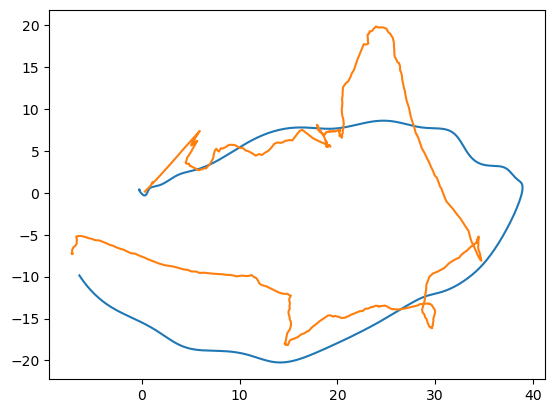

In [155]:
interval = test_intervals[6]

t_pred, pos_pred = analysis.predict_decoder(interval,interpolate=True,smooth_context = 40)
pos_pred.shape

ind_pos = np.logical_and(behavior_df.index.values >= interval[0], behavior_df.index.values <= interval[1]
                         )
plt.plot(behavior_df.loc[ind_pos, feature_names[0]], behavior_df.loc[ind_pos, feature_names[1]])
plt.plot(pos_pred[:,0], pos_pred[:,1])

In [165]:
np.sum(ind_pos),pos_pred.shape

(np.int64(600), (600, 2))

In [149]:
t_pred.min(), behavior_df.loc[ind_pos].index.values.min(), t_pred.max(), behavior_df.loc[ind_pos].index.values.max()

(np.float64(2028.9540000000018),
 np.float64(2028.955),
 np.float64(2029.553000000002),
 np.float64(2029.554))

# Reach direction Decode

In [156]:
window = (-.1,.5)

train_df = trials_df[trials_df.split == "train"]
train_df = train_df[train_df.ctr_hold_bump == False][:-11]
train_trial_reach_cat = np.empty(len(train_df), dtype=int)
categories = train_df.cond_dir.unique()
np.sort(categories)
for i, cond_dir in enumerate(categories):
    train_trial_reach_cat[train_df.cond_dir == cond_dir] = i
result = analysis.alligned_response(train_df.move_onset_time.values, t_plot = window)
result=result.mean(axis=1)


test_df = trials_df[trials_df.split == "val"]
print(len(test_df))
test_df = test_df[test_df.ctr_hold_bump == False][1:]
print(len(test_df))
test_trial_reach_cat = np.empty(len(test_df), dtype=int)
for i, cond_dir in enumerate(categories):
    test_trial_reach_cat[test_df.cond_dir == cond_dir] = i
result_test = analysis.alligned_response(test_df.move_onset_time.values, t_plot = window)
result_test=result_test.mean(axis=1)
result_test.shape, test_trial_reach_cat.shape


from sklearn.linear_model import LogisticRegression
model = LogisticRegression(multi_class="multinomial", max_iter=200)
model.fit(result, train_trial_reach_cat)
# Predict categories
predictions = model.predict(result)
test_predictions = model.predict(result_test)

train_accuracy = np.mean(predictions == train_trial_reach_cat)
test_accuracy = np.mean(test_predictions == test_trial_reach_cat)

print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


92
51
Train accuracy: 0.8692
Test accuracy: 0.8431


/home/sambray/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


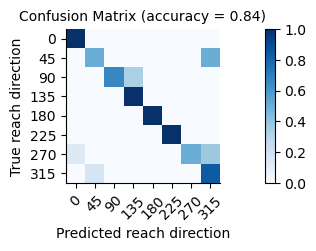

In [157]:
# confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_trial_reach_cat, test_predictions, normalize='true')  # Normalize the confusion matrix
fig, ax_list = plt.subplots(figsize=(3,2),ncols=2, width_ratios=[1,0.05])
ax = ax_list[0]
cm = ax.matshow(cm, cmap=plt.cm.Blues)
plt.colorbar(cm, cax=ax_list[1])
ax.tick_params(axis="x", bottom=True, labelbottom=True)
ax.set_xlabel("Predicted reach direction")
ax.set_ylabel("True reach direction")
ax.xaxis.set_ticks_position("bottom")
ax.xaxis.set_label_position("bottom")
ax.set_xticks(ticks=np.arange(len(categories)).astype(int), labels=np.sort(categories).astype(int), rotation=45,)
ax.set_yticks(ticks=np.arange(len(categories)).astype(int), labels=np.sort(categories).astype(int))


ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Confusion Matrix (accuracy = {:.2f})".format(test_accuracy), fontsize=10)
fig.savefig(figure_folder / "confusion_matrix.svg",)

In [49]:
figure_folder

PosixPath('/home/sambray/Documents/c3po/Figures/monkey_s1_reach/monkey_s1_bump_reach_2026_REACH_ONLY_8d')

## Active/Passive Decode

In [158]:
window = (-.1,.5)

train_df = trials_df[trials_df.split == "train"][:-17]
# train_df = train_df[train_df.ctr_hold_bump == False][:-11]
train_trial_reach_cat = np.empty(len(train_df), dtype=int)
categories = [True, False]
np.sort(categories)
for i, trial_type in enumerate(categories):
    train_trial_reach_cat[train_df.ctr_hold_bump == trial_type] = i
result = analysis.alligned_response(train_df.move_onset_time.values, t_plot = window)
result=result.mean(axis=1)

# print(result.shape, train_trial_reach_cat.shape)


test_df = trials_df[trials_df.split == "val"][1:-3]
# print(len(test_df))
# test_df = test_df[test_df.ctr_hold_bump == False][1:]
# print(len(test_df))
test_trial_reach_cat = np.empty(len(test_df), dtype=int)
for i, trial_type in enumerate(categories):
    test_trial_reach_cat[test_df.ctr_hold_bump == trial_type] = i
result_test = analysis.alligned_response(test_df.move_onset_time.values, t_plot = window)
result_test=result_test.mean(axis=1)
result_test.shape, test_trial_reach_cat.shape


from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=200)
model.fit(result, train_trial_reach_cat)
# Predict categories
predictions = model.predict(result)
test_predictions = model.predict(result_test)

train_accuracy = np.mean(predictions == train_trial_reach_cat)
test_accuracy = np.mean(test_predictions == test_trial_reach_cat)

print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


Train accuracy: 0.8980
Test accuracy: 0.9545


# Neuron Embeddings

In [159]:
W = analysis.params['params']['embedding']['encoder']['encoder_matrix']
z_neuron = W @ analysis.pca.components_.T

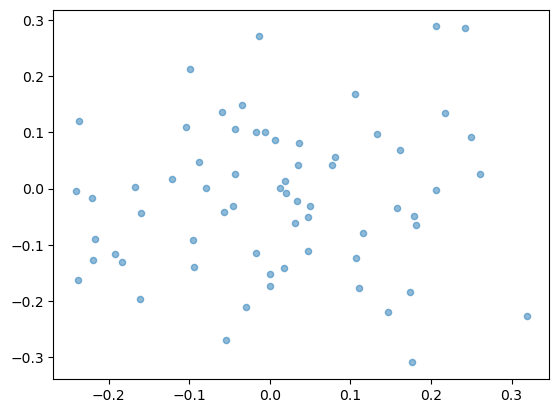

In [160]:
pc_to_plot = (0,1)
plt.scatter(z_neuron[:,pc_to_plot[0]], z_neuron[:,pc_to_plot[1]], s=20, alpha=0.5)

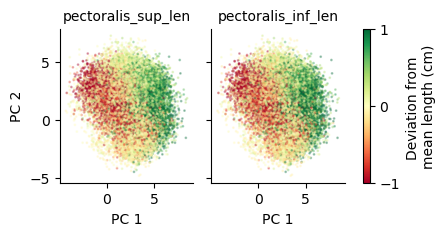

In [164]:
ind_plot = slice(None,None,10)
from c3po.analysis.analysis import interval_list_contains_ind

_df = trials_df[trials_df.ctr_hold_bump == False]
intervals = np.array([
    [start + 0, start + .5] for start in _df.move_onset_time.values
])

ind_plot = interval_list_contains_ind(intervals, analysis.t)[::3]

pc_to_plot = (0,1)
t_feature = behavior_df.index.values
feature_name = "hand_vel_x"
feature_name = ["pectoralis_sup_len","pectoralis_inf_len"]
feature = expanded_behavior_df[feature_name].values
feature = feature - np.nanmean(feature, axis=0)
feature = feature * 100 # (to convert to cm)



cmap = "PiYG"
cmap = "RdYlGn"


ind_feature = np.digitize(analysis.t[ind_plot], t_feature) - 1
lim = 1

fig, ax = plt.subplots(ncols=3, figsize=(4,2), width_ratios=[1,1,0.05])

for i, a in enumerate(ax.flatten()[:-1]):
    a.set_title(feature_name[i],fontsize=10)
    cm = a.scatter(analysis.c_pca[ind_plot][:,pc_to_plot[0]], analysis.c_pca[ind_plot][:,pc_to_plot[1]],
                c=feature[ind_feature,i], s=1, alpha=0.3, cmap=cmap,
                clim=(-lim, lim) if lim is not None else None,
                rasterized=True)
    a.spines[["top", "right"]].set_visible(False)
    a.set_xlabel(f"PC {pc_to_plot[0]+1}")

ax[1].set_yticklabels([])
ax[0].set_ylabel(f"PC {pc_to_plot[1]+1}")

cbar = plt.colorbar(cm, cax=ax.flatten()[-1], label="Deviation from \nmean length (cm)",
             ticks=[-lim, 0, lim] if lim is not None else None)
cbar.solids.set_alpha(1)
fig.savefig(figure_folder / f"c_pca_{feature_name[0]}_{feature_name[1]}.svg",)

In [151]:
figure_folder

PosixPath('/home/sambray/Documents/c3po/Figures/monkey_s1_reach/monkey_s1_bump_reach_2026_REACH_ONLY_8d')

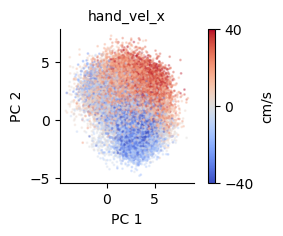

In [165]:
ind_plot = slice(None,None,10)
from c3po.analysis.analysis import interval_list_contains_ind

_df = trials_df[trials_df.ctr_hold_bump == False]
intervals = np.array([
    [start + 0, start + .5] for start in _df.move_onset_time.values
])

ind_plot = interval_list_contains_ind(intervals, analysis.t)[::3]

pc_to_plot = (0,1)
t_feature = behavior_df.index.values
feature_name = ["hand_vel_x"]
# feature_name = ["pectoralis_sup_len","pectoralis_inf_len"]
feature = expanded_behavior_df[feature_name].values
feature = feature - np.nanmean(feature, axis=0)
# feature = feature * 100 # (to convert to cm)



cmap = "PiYG"
cmap = "coolwarm"


ind_feature = np.digitize(analysis.t[ind_plot], t_feature) - 1
lim = 40

fig, ax = plt.subplots(ncols=len(feature_name)+1, figsize=(2,2), width_ratios=[1]*len(feature_name) + [0.05])

for i, a in enumerate(ax.flatten()[:-1]):
    a.set_title(feature_name[i],fontsize=10)
    cm = a.scatter(analysis.c_pca[ind_plot][:,pc_to_plot[0]], analysis.c_pca[ind_plot][:,pc_to_plot[1]],
                c=feature[ind_feature,i], s=1, alpha=0.3, cmap=cmap,
                clim=(-lim, lim) if lim is not None else None,
                rasterized=True)
    a.spines[["top", "right"]].set_visible(False)
    a.set_xlabel(f"PC {pc_to_plot[0]+1}")

ax[1].set_yticklabels([])
ax[0].set_ylabel(f"PC {pc_to_plot[1]+1}")

cbar = plt.colorbar(cm, cax=ax.flatten()[-1], label="cm/s",
             ticks=[-lim, 0, lim] if lim is not None else None)
cbar.solids.set_alpha(1)
fig.savefig(figure_folder / f"c_pca_{feature_name[0]}.svg",)

In [ ]:
ind_plot = slice(None,None,10)
from c3po.analysis.analysis import interval_list_contains_ind

_df = trials_df[trials_df.ctr_hold_bump == False]
intervals = np.array([
    [start + 0, start + .5] for start in _df.move_onset_time.values
])

ind_plot = interval_list_contains_ind(intervals, analysis.t)[::3]

pc_to_plot = (0,1)
t_feature = behavior_df.index.values
feature_name = ["hand_vel_x"]
# feature_name = ["pectoralis_sup_len","pectoralis_inf_len"]
feature = expanded_behavior_df[feature_name].values
feature = feature - np.nanmean(feature, axis=0)
# feature = feature * 100 # (to convert to cm)



cmap = "PiYG"
cmap = "coolwarm"


ind_feature = np.digitize(analysis.t[ind_plot], t_feature) - 1
lim = 40

fig, ax = plt.subplots(ncols=len(feature_name)+1, figsize=(2,2), width_ratios=[1]*len(feature_name) + [0.05])

for i, a in enumerate(ax.flatten()[:-1]):
    a.set_title(feature_name[i],fontsize=10)
    cm = a.scatter(analysis.c_pca[ind_plot][:,pc_to_plot[0]], analysis.c_pca[ind_plot][:,pc_to_plot[1]],
                c=feature[ind_feature,i], s=1, alpha=0.3, cmap=cmap,
                clim=(-lim, lim) if lim is not None else None)
    a.spines[["top", "right"]].set_visible(False)
    a.set_xlabel(f"PC {pc_to_plot[0]+1}")

ax[1].set_yticklabels([])
ax[0].set_ylabel(f"PC {pc_to_plot[1]+1}")

cbar = plt.colorbar(cm, cax=ax.flatten()[-1], label="cm/s",
             ticks=[-lim, 0, lim] if lim is not None else None)
cbar.solids.set_alpha(1)
fig.savefig(figure_folder / f"c_pca_{feature_name[0]}.svg",)

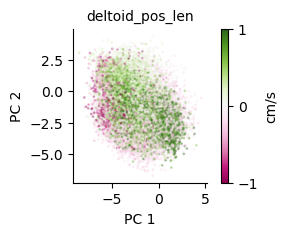

In [150]:
ind_plot = slice(None,None,10)
from c3po.analysis.analysis import interval_list_contains_ind

_df = trials_df[trials_df.ctr_hold_bump == False]
intervals = np.array([
    [start + 0, start + .5] for start in _df.move_onset_time.values
])

ind_plot = interval_list_contains_ind(intervals, analysis.t)[::3]

pc_to_plot = (0,1)
t_feature = behavior_df.index.values
feature_name = ["deltoid_pos_len"]
# feature_name = ["pectoralis_sup_len","pectoralis_inf_len"]
feature = expanded_behavior_df[feature_name].values
feature = feature - np.nanmean(feature, axis=0)
feature = feature * 100 # (to convert to cm)



cmap = "PiYG"
# cmap = "coolwarm"


ind_feature = np.digitize(analysis.t[ind_plot], t_feature) - 1
lim = 1

fig, ax = plt.subplots(ncols=len(feature_name)+1, figsize=(2,2), width_ratios=[1]*len(feature_name) + [0.05])

for i, a in enumerate(ax.flatten()[:-1]):
    a.set_title(feature_name[i],fontsize=10)
    cm = a.scatter(analysis.c_pca[ind_plot][:,pc_to_plot[0]], analysis.c_pca[ind_plot][:,pc_to_plot[1]],
                c=feature[ind_feature,i], s=1, alpha=0.3, cmap=cmap,
                clim=(-lim, lim) if lim is not None else None)
    a.spines[["top", "right"]].set_visible(False)
    a.set_xlabel(f"PC {pc_to_plot[0]+1}")

ax[1].set_yticklabels([])
ax[0].set_ylabel(f"PC {pc_to_plot[1]+1}")

cbar = plt.colorbar(cm, cax=ax.flatten()[-1], label="cm/s",
             ticks=[-lim, 0, lim] if lim is not None else None)
cbar.solids.set_alpha(1)
# fig.savefig(figure_folder / f"c_pca_{feature_name[0]}.svg",)

In [75]:
muscle_behavior_df.columns

Index(['abd_poll_longus_vel', 'abd_poll_longus_len', 'anconeus_vel',
       'anconeus_len', 'bicep_lh_vel', 'bicep_lh_len', 'bicep_sh_vel',
       'bicep_sh_len', 'brachialis_vel', 'brachialis_len',
       'brachioradialis_vel', 'brachioradialis_len', 'coracobrachialis_vel',
       'coracobrachialis_len', 'deltoid_ant_vel', 'deltoid_ant_len',
       'deltoid_med_vel', 'deltoid_med_len', 'deltoid_pos_vel',
       'deltoid_pos_len', 'dorsoepitrochlearis_vel', 'dorsoepitrochlearis_len',
       'ext_carpi_rad_longus_vel', 'ext_carpi_rad_longus_len',
       'ext_carp_rad_brevis_vel', 'ext_carp_rad_brevis_len',
       'ext_carpi_ulnaris_vel', 'ext_carpi_ulnaris_len', 'ext_digitorum_vel',
       'ext_digitorum_len', 'ext_digiti_vel', 'ext_digiti_len',
       'ext_indicis_vel', 'ext_indicis_len', 'flex_carpi_radialis_vel',
       'flex_carpi_radialis_len', 'flex_carpi_ulnaris_vel',
       'flex_carpi_ulnaris_len', 'flex_digit_profundus_vel',
       'flex_digit_profundus_len', 'flex_digit_super